In [200]:
import pandas as pd
import numpy as np

In [201]:
df = pd.read_csv(r"C:\Users\ROHIT RANE\Downloads\Dataset\spam.csv", encoding = 'latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


# Data Cleaning

In [202]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [203]:
# Drop last columns
df.drop(columns = ['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis = 1, inplace = True)

In [204]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [205]:
# Rename the columns
df.rename(columns = {'v1' : 'Target', 'v2' : 'Text'}, inplace = True)

In [206]:
df.head()

,Target,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [207]:
from sklearn.preprocessing import LabelEncoder

In [208]:
le = LabelEncoder()

In [209]:
df['Target'] = le.fit_transform(df['Target'])

In [210]:
df.head()

,Target,Text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [211]:
# Checking missing values
df.isnull().sum()

Target    0
Text      0
dtype: int64

In [212]:
# Checking duplicates values
df.duplicated().sum()

403

In [213]:
# Remove duplicate
df.drop_duplicates(keep = 'first', inplace = True)

In [214]:
df.duplicated().sum()

0

In [215]:
df.shape

(5169, 2)

# EDA - Exploratory Data Analysis

In [216]:
df.head()

,Target,Text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [217]:
df['Target'].value_counts()

Target
0    4516
1     653
Name: count, dtype: int64

In [218]:
import matplotlib.pyplot as plt

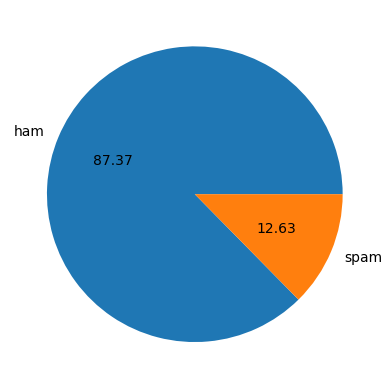

In [219]:
plt.pie(df['Target'].value_counts(), labels = ['ham', 'spam'], autopct = "%0.2f")
plt.show()

In [220]:
import nltk

In [221]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to C:\Users\ROHIT
[nltk_data]     RANE\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [222]:
# number of characters
df['num_characters'] = df['Text'].apply(len)

In [223]:
df.head()

,Target,Text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [224]:
# number of words
df['num_words'] = df['Text'].apply(lambda x : len(nltk.word_tokenize(x)))

In [225]:
df.head()

,Target,Text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [226]:
# number of sentences
df['num_sentences'] = df['Text'].apply(lambda x : len(nltk.sent_tokenize(x)))

In [227]:
df.head()

,Target,Text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [228]:
df[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [229]:
#ham messages
df[df['Target'] == 0][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [230]:
# spam messages
df[df['Target'] == 1][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [231]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

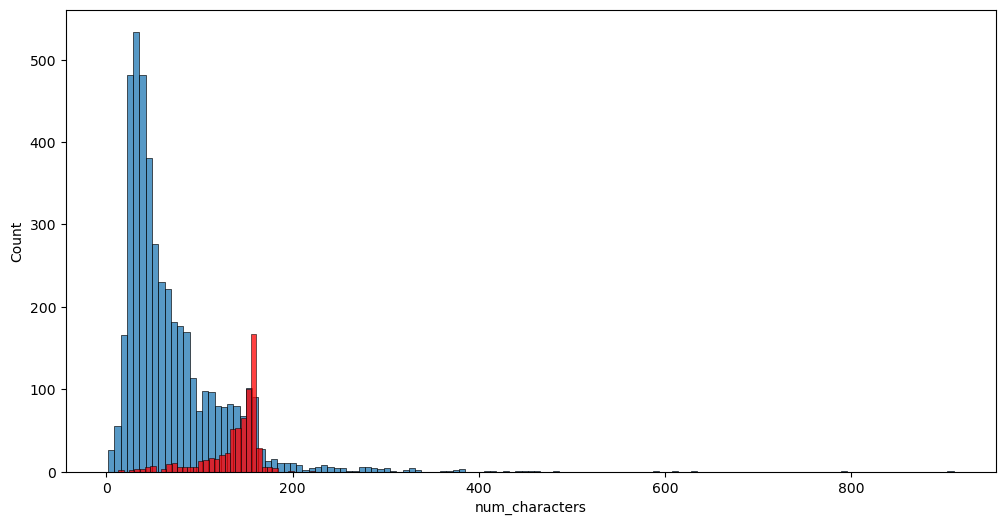

In [232]:
plt.figure(figsize = (12, 6))
sns.histplot(df[df['Target'] == 0]['num_characters'])
sns.histplot(df[df['Target'] == 1]['num_characters'], color = 'red')

<Axes: xlabel='num_words', ylabel='Count'>

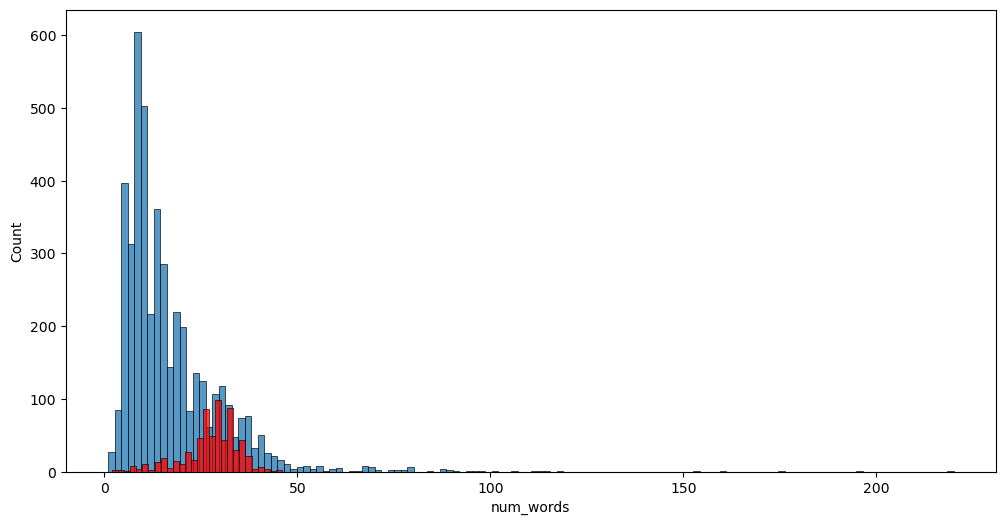

In [233]:
plt.figure(figsize = (12, 6))
sns.histplot(df[df['Target'] == 0]['num_words'])
sns.histplot(df[df['Target'] == 1]['num_words'], color = 'red')

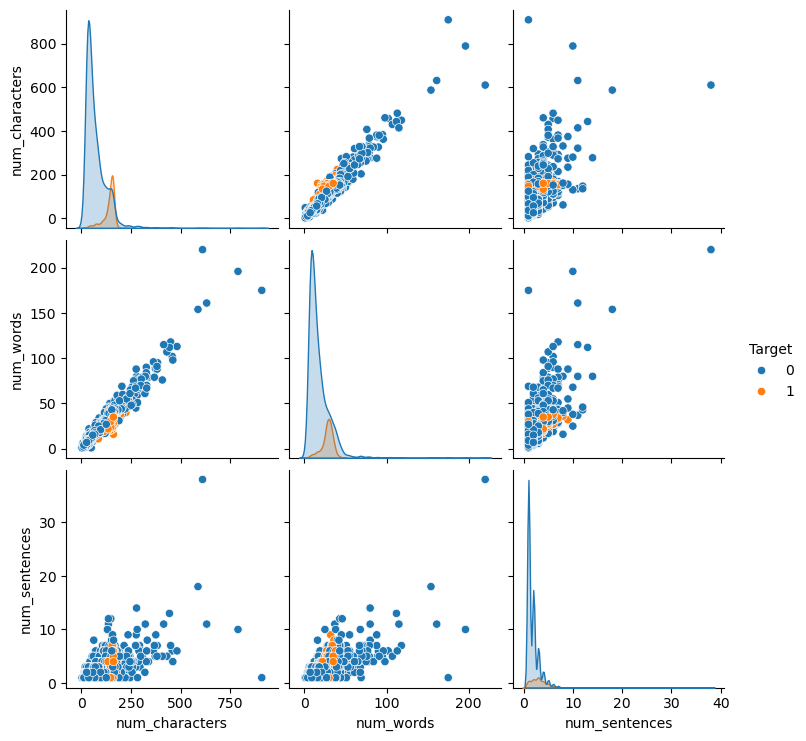

In [234]:
sns.pairplot(df, hue = 'Target')

# Data preprocessing
- Lower case
- Tokenization
- Removing special characters
- Removing stop words and punctuation
- Stemming

In [235]:
import string
# string.punctuation

In [236]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
ps = PorterStemmer()

In [237]:
def transform_text(text):
    text = text.lower()

    text = nltk.word_tokenize(text)

    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))
            
    return " ".join(y)

In [238]:
df['transformed_text'] = df['Text'].apply(transform_text)

In [239]:
df.head()

,Target,Text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [240]:
from wordcloud import WordCloud

In [241]:
wc = WordCloud(width = 500, height = 500, min_font_size = 10, background_color = 'white')

In [242]:
spam_wc = wc.generate(df[df['Target'] == 1]['transformed_text'].str.cat(sep = " "))

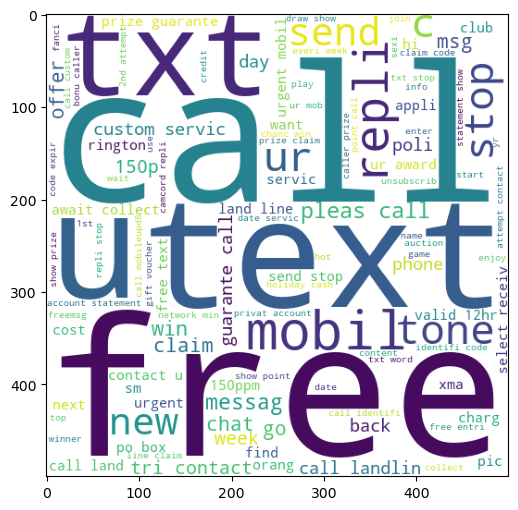

In [243]:
plt.figure(figsize = (15, 6))
plt.imshow(spam_wc)

In [244]:
ham_wc = wc.generate(df[df['Target'] == 0]['transformed_text'].str.cat(sep = " "))

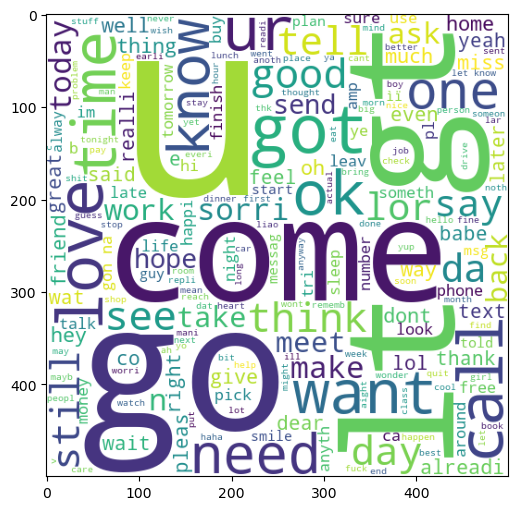

In [245]:
plt.figure(figsize = (15, 6))
plt.imshow(ham_wc)

In [246]:
spam_corpus = []
for message in df[df['Target'] == 1]['transformed_text'].tolist():
    for word in message.split():
        spam_corpus.append(word)

In [247]:
len(spam_corpus)

9939

In [248]:
from collections import Counter

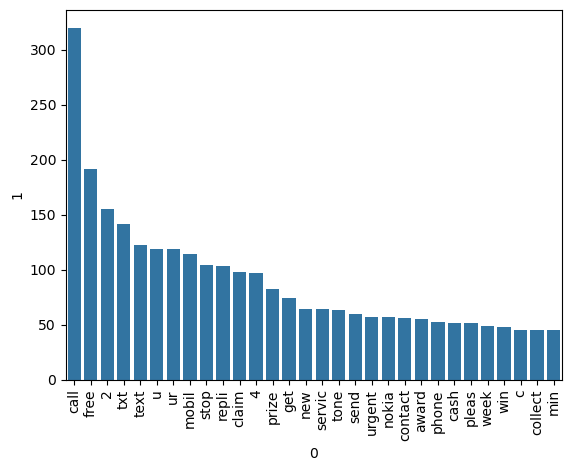

In [249]:
sns.barplot(x = pd.DataFrame(Counter(spam_corpus).most_common(30))[0], y = pd.DataFrame(Counter(spam_corpus).most_common(30))[1])
plt.xticks(rotation = 'vertical')
plt.show()

In [250]:
ham_corpus = []
for message in df[df['Target'] == 0]['transformed_text'].tolist():
    for word in message.split():
        ham_corpus.append(word)

In [251]:
len(ham_corpus)

35404

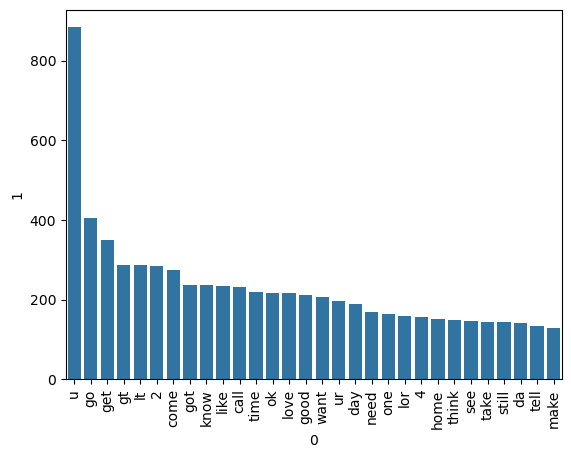

In [252]:
sns.barplot(x = pd.DataFrame(Counter(ham_corpus).most_common(30))[0], y = pd.DataFrame(Counter(ham_corpus).most_common(30))[1])
plt.xticks(rotation = 'vertical')
plt.show()

# Model Building

In [344]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [408]:
# cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features = 5000)

In [409]:
x = tfidf.fit_transform(df['transformed_text']).toarray()

In [410]:
x.shape

(5169, 5000)

In [411]:
y = df['Target'].values

In [412]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [413]:
from sklearn.model_selection import train_test_split

In [414]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)

In [415]:
x_train.shape, x_test.shape

((3618, 5000), (1551, 5000))

In [416]:
y_train.shape, y_test.shape

((3618,), (1551,))

In [417]:
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, recall_score, precision_score, confusion_matrix

In [418]:
gnb = GaussianNB()
bnb = BernoulliNB()
mnb = MultinomialNB()

In [419]:
gnb.fit(x_train, y_train)

y_pred_1 = gnb.predict(x_test)
print(classification_report(y_test, y_pred_1))
print(confusion_matrix(y_test, y_pred_1))
print(f'accuracy score : {accuracy_score(y_test, y_pred_1)}')
print(f'recall score : {recall_score(y_test, y_pred_1)}')
print(f'precision score : {precision_score(y_test, y_pred_1)}')

              precision    recall  f1-score   support

           0       0.97      0.88      0.92      1331
           1       0.54      0.85      0.66       220

    accuracy                           0.87      1551
   macro avg       0.75      0.86      0.79      1551
weighted avg       0.91      0.87      0.89      1551

[[1171  160]
 [  34  186]]
accuracy score : 0.8749194068343005
recall score : 0.8454545454545455
precision score : 0.5375722543352601


In [420]:
bnb.fit(x_train, y_train)

y_pred_2 = bnb.predict(x_test)
print(classification_report(y_test, y_pred_2))
print(confusion_matrix(y_test, y_pred_2))
print(f'accuracy score : {accuracy_score(y_test, y_pred_2)}')
print(f'recall score : {recall_score(y_test, y_pred_2)}')
print(f'precision score : {precision_score(y_test, y_pred_2)}')

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1331
           1       0.98      0.80      0.89       220

    accuracy                           0.97      1551
   macro avg       0.98      0.90      0.93      1551
weighted avg       0.97      0.97      0.97      1551

[[1328    3]
 [  43  177]]
accuracy score : 0.970341715022566
recall score : 0.8045454545454546
precision score : 0.9833333333333333


In [422]:
mnb.fit(x_train, y_train)

y_pred_3 = mnb.predict(x_test)
print(classification_report(y_test, y_pred_3))
print(confusion_matrix(y_test, y_pred_3))
print(f'accuracy score : {accuracy_score(y_test, y_pred_3)}')
print(f'recall score : {recall_score(y_test, y_pred_3)}')
print(f'precision score : {precision_score(y_test, y_pred_3)}')

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1331
           1       1.00      0.73      0.84       220

    accuracy                           0.96      1551
   macro avg       0.98      0.86      0.91      1551
weighted avg       0.96      0.96      0.96      1551

[[1331    0]
 [  60  160]]
accuracy score : 0.9613152804642167
recall score : 0.7272727272727273
precision score : 1.0


In [381]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [382]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=42)
abc = AdaBoostClassifier(n_estimators=50, random_state=42)
bc = BaggingClassifier(n_estimators=50, random_state=42)
etc = ExtraTreesClassifier(n_estimators=50, random_state=42)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=42)
xgb = XGBClassifier(n_estimators=50,random_state=42)

In [383]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [384]:
def train_classifier(clf, x_train, y_train, x_test, y_test):
    clf.fit(x_train, y_train)
    y_pred = clf.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)

    return accuracy, precision

In [385]:
train_classifier(svc, x_train, y_train, x_test, y_test)

(0.9787234042553191, 0.9698492462311558)

In [386]:
accuracy_scores = []
precision_scores = []

for name, clf in clfs.items():

    current_accuracy, current_precision = train_classifier(clf, x_train, y_train, x_test, y_test)

    print(f'Name : {name}')
    print(f'Accuracy : {current_accuracy}')
    print(f'Precision : {current_precision}')

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

Name : SVC
Accuracy : 0.9787234042553191
Precision : 0.9698492462311558
Name : KN
Accuracy : 0.900709219858156
Precision : 1.0
Name : NB
Accuracy : 0.9716312056737588
Precision : 0.9888888888888889
Name : DT
Accuracy : 0.9348807221147647
Precision : 0.8650306748466258
Name : LR
Accuracy : 0.9451966473243069
Precision : 0.8947368421052632
Name : RF
Accuracy : 0.9742101869761445
Precision : 0.9945054945054945
Name : AdaBoost
Accuracy : 0.9136041263700838
Precision : 0.7986111111111112
Name : BgC
Accuracy : 0.9626047711154094
Precision : 0.8820754716981132
Name : ETC
Accuracy : 0.9748549323017408
Precision : 0.9788359788359788
Name : GBDT
Accuracy : 0.9484203739522888
Precision : 0.9605263157894737
Name : xgb
Accuracy : 0.9658284977433914
Precision : 0.946524064171123


In [365]:
performance_df = pd.DataFrame({'Algorithm' : clfs.keys(), 'Accuracy' : accuracy_scores, 'Precision' : precision_scores}).sort_values('Precision', ascending = False)

In [366]:
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.888459,1.000000
2,NB,0.954223,1.000000
5,RF,0.965184,0.994048
8,ETC,0.974210,0.989130
0,SVC,0.972276,0.968254
10,xgb,0.970342,0.957895
9,GBDT,0.947776,0.926380
7,BgC,0.963894,0.901961
4,LR,0.941973,0.886905
3,DT,0.934236,0.835227


In [387]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores}).sort_values('Precision_max_ft_3000',ascending=False)

In [388]:
temp_df

,Algorithm,Accuracy_max_ft_3000,Precision_max_ft_3000
1,KN,0.900709,1.000000
5,RF,0.974210,0.994505
2,NB,0.971631,0.988889
8,ETC,0.974855,0.978836
0,SVC,0.978723,0.969849
9,GBDT,0.948420,0.960526
10,xgb,0.965828,0.946524
4,LR,0.945197,0.894737
7,BgC,0.962605,0.882075
3,DT,0.934881,0.865031


In [391]:
new_df = performance_df.merge(temp_df, on = 'Algorithm')

In [392]:
new_df

,Algorithm,Accuracy,Precision,Accuracy_max_ft_3000,Precision_max_ft_3000
0,KN,0.888459,1.000000,0.900709,1.000000
1,NB,0.954223,1.000000,0.971631,0.988889
2,RF,0.965184,0.994048,0.974210,0.994505
3,ETC,0.974210,0.989130,0.974855,0.978836
4,SVC,0.972276,0.968254,0.978723,0.969849
5,xgb,0.970342,0.957895,0.965828,0.946524
6,GBDT,0.947776,0.926380,0.948420,0.960526
7,BgC,0.963894,0.901961,0.962605,0.882075
8,LR,0.941973,0.886905,0.945197,0.894737
9,DT,0.934236,0.835227,0.934881,0.865031


In [393]:
import pickle

In [424]:
pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))
pickle.dump(mnb, open('model.pkl', 'wb'))